# MYTIGATE — Scenario Test Notebook

Self-contained. Checks what is already precomputed before running anything.

**Load order:**
- Grid: `baseline.gpkg` if it exists (has M2+M3+M4), else `grid_base.gpkg`
- Baseline env: loads from `grid_env_*.gpkg` caches if present, else runs M1
- Scenario env: loads from precomputed SSP gpkg files if `SCENARIO_ACTIVE=True`
- M2/M3/M4: always run live (fast)

**Prerequisites:**
- `grid_base.gpkg` exists (built by grid cell in debug notebook)
- `grid_env_*.gpkg` baseline caches exist (built by M1 cell in debug notebook)
- For scenarios: `python pipeline.py --precompute-scenarios --skip-baseline`

## Cell 1 — Configuration

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from config import (
    GRID_GPKG, BASELINE_GPKG, PRIMARY_HARVEST,
    GRID_ENV_TEMP_GPKG, GRID_ENV_SAL_GPKG,
    GRID_ENV_CHLA_GPKG, GRID_ENV_FLOW_GPKG,
    LONGLINE_LENGTH, LONGLINE_SPACING, LONGLINES_PER_SECTION, N_SECTIONS_DEFAULT,
)
from config_scenario import SSP_SCENARIOS, PERIODS, scenario_gpkg
from utils.climate_projections import load_scenario_env
from utils.raster_sampler import run_module1
from model.growth import run_module2, run_module3, run_module4, N_CPU

# ── Edit these ────────────────────────────────────────────────────────────────
SCENARIO_ACTIVE = True
ACTIVE_SSP      = 'ssp2_4_5'   # ssp1_2_6 | ssp2_4_5 | ssp3_7_0 | ssp5_8_5
ACTIVE_PERIOD   = 'end'        # mid (2041-2060) | end (2071-2100)
HARVEST_MONTH   = PRIMARY_HARVEST   # 11 = November
N_SC            = 50           # MC scenarios — 50 for speed, 500 for production
MAX_RDEP        = 2.0
ILOOP           = 0.7
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 8)
WEBMERCATOR = 'EPSG:3857'

def add_basemap(ax):
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7)
    except Exception as e:
        print(f'  Basemap unavailable: {e}')

m = f'{HARVEST_MONTH:02d}'

print(f'Harvest month   : {HARVEST_MONTH}')
print(f'MC scenarios    : {N_SC}')
print(f'Scenario active : {SCENARIO_ACTIVE}')
if SCENARIO_ACTIVE:
    print(f'  SSP    : {SSP_SCENARIOS[ACTIVE_SSP]}')
    print(f'  Period : {ACTIVE_PERIOD}  ({PERIODS[ACTIVE_PERIOD][0][:4]}–{PERIODS[ACTIVE_PERIOD][1][:4]})')

Harvest month   : 11
MC scenarios    : 50
Scenario active : True
  SSP    : SSP2-4.5  (~2.7°C)
  Period : end  (2071–2100)


## Cell 2 — Load grid

In [2]:
# Try baseline.gpkg first (has M2+M3+M4 columns) — fall back to grid_base.gpkg
if BASELINE_GPKG.exists():
    print(f'Loading baseline.gpkg (full output)...')
    grid = gpd.read_file(BASELINE_GPKG)
    print(f'  Source : baseline.gpkg')
else:
    print(f'baseline.gpkg not found — loading grid_base.gpkg...')
    grid = gpd.read_file(GRID_GPKG)
    print(f'  Source : grid_base.gpkg')

print(f'  Cells  : {len(grid):,}')
print(f'  CRS    : {grid.crs}')

# Report what is already present
has_bathy      = 'bathymetry_m' in grid.columns
has_exclusions = 'excluded' in grid.columns
has_env        = 'temp_mean_01' in grid.columns
has_m2         = f'mbio_p50_{m}' in grid.columns
has_m3         = f'N_red_{m}' in grid.columns

print(f'\n  Already present:')
print(f'    bathymetry  : {has_bathy}')
print(f'    exclusions  : {has_exclusions}')
print(f'    env (M1)    : {has_env}')
print(f'    M2 outputs  : {has_m2}')
print(f'    M3 outputs  : {has_m3}')

Loading baseline.gpkg (full output)...
  Source : baseline.gpkg
  Cells  : 61,060
  CRS    : EPSG:32632

  Already present:
    bathymetry  : True
    exclusions  : True
    env (M1)    : True
    M2 outputs  : True
    M3 outputs  : True


## Cell 3 — M1 baseline env

In [3]:
# Check if all 4 per-variable env cache files exist
_env_caches = {
    'temp': GRID_ENV_TEMP_GPKG,
    'sal':  GRID_ENV_SAL_GPKG,
    'chla': GRID_ENV_CHLA_GPKG,
    'flow': GRID_ENV_FLOW_GPKG,
}
_caches_exist = {var: p.exists() for var, p in _env_caches.items()}
all_caches_exist = all(_caches_exist.values())

print('Baseline env cache status:')
for var, p in _env_caches.items():
    status = 'OK' if _caches_exist[var] else 'MISSING'
    print(f'  {var:6s} [{status}]  {p.name}')

if 'temp_mean_01' in grid.columns:
    # Already loaded from baseline.gpkg — nothing to do
    print('\nEnv columns already in grid — skipping M1')
    grid_baseline_env = grid.copy()

elif all_caches_exist:
    # Load from per-variable cache files and merge onto grid
    print('\nAll env caches present — loading and merging...')
    grid_baseline_env = run_module1(grid, force_resample=False)

else:
    # Cache files missing — run full M1 (samples CMEMS)
    missing = [var for var, ok in _caches_exist.items() if not ok]
    print(f'\nMissing caches: {missing} — running M1 from CMEMS...')
    grid_baseline_env = run_module1(grid, force_resample=False)

print(f"\n  temp_mean_{m} : {grid_baseline_env[f'temp_mean_{m}'].mean():.2f} °C")
print(f"  sal_mean_{m}  : {grid_baseline_env[f'sal_mean_{m}'].mean():.2f} psu")
print(f"  lnchla_{m}   : {grid_baseline_env[f'lnchla_mean_{m}'].mean():.3f} ln(µg/L)")
print(f"  vh_{m}        : {grid_baseline_env[f'vh_{m}'].mean():.4f} m/s")

Baseline env cache status:
  temp   [OK]  grid_env_temp.gpkg
  sal    [OK]  grid_env_sal.gpkg
  chla   [OK]  grid_env_chla.gpkg
  flow   [OK]  grid_env_flow.gpkg

Env columns already in grid — skipping M1

  temp_mean_11 : 9.22 °C
  sal_mean_11  : 23.03 psu
  lnchla_11   : -0.032 ln(µg/L)
  vh_11        : 0.0946 m/s


## Cell 4 — M1 scenario env

In [4]:
if not SCENARIO_ACTIVE:
    print('SCENARIO_ACTIVE = False — scenario env not loaded')
    print('M2/M3/M4 will run on baseline env only')
    grid_scenario_env = None

else:
    # Check which scenario gpkg files exist
    _scen_paths = scenario_gpkg(ACTIVE_SSP, ACTIVE_PERIOD)
    _scen_exist = {var: p.exists() for var, p in _scen_paths.items()}
    all_scen_exist = all(_scen_exist.values())

    print(f'Scenario: {SSP_SCENARIOS[ACTIVE_SSP]} / {ACTIVE_PERIOD}')
    print('Scenario env file status:')
    for var, p in _scen_paths.items():
        status = 'OK' if _scen_exist[var] else 'MISSING'
        print(f'  {var:6s} [{status}]  {p.name}')

    if not all_scen_exist:
        missing = [var for var, ok in _scen_exist.items() if not ok]
        raise FileNotFoundError(
            f'Scenario files missing: {missing}\n'
            f'Run: python pipeline.py --precompute-scenarios --skip-baseline'
        )

    # Load scenario env onto base grid structure (non-env columns preserved)
    grid_scenario_env = load_scenario_env(grid, ssp=ACTIVE_SSP, period=ACTIVE_PERIOD)

    # Show env deltas vs baseline
    print(f'\nEnv deltas vs baseline (month {m}):')
    for col, unit in [
        (f'temp_mean_{m}',   '°C'),
        (f'sal_mean_{m}',    'psu'),
        (f'lnchla_mean_{m}', 'ln units'),
        (f'vh_{m}',          'm/s'),
    ]:
        b = grid_baseline_env[col].mean()
        s = grid_scenario_env[col].mean()
        print(f'  {col:22s}  baseline={b:.4f}  scenario={s:.4f}  Δ={s-b:+.4f} {unit}')

Scenario: SSP2-4.5  (~2.7°C) / end
Scenario env file status:
  temp   [OK]  grid_env_temp_ssp2_4_5_end.gpkg
  sal    [OK]  grid_env_sal_ssp2_4_5_end.gpkg
  chla   [OK]  grid_env_chla_ssp2_4_5_end.gpkg
  flow   [OK]  grid_env_flow_ssp2_4_5_end.gpkg

=== load_scenario_env: SSP2-4.5 / end ===
  [LOAD] temp   → grid_env_temp_ssp2_4_5_end.gpkg  (24 columns)
  [LOAD] sal    → grid_env_sal_ssp2_4_5_end.gpkg  (24 columns)
  [LOAD] chla   → grid_env_chla_ssp2_4_5_end.gpkg  (24 columns)
  [LOAD] flow   → grid_env_flow_ssp2_4_5_end.gpkg  (36 columns)
  [OK] env_source = CMIP6:ssp2_4_5:end
  [OK] Grid ready for Module 2 (61,060 cells)

Env deltas vs baseline (month 11):
  temp_mean_11            baseline=9.2185  scenario=10.7942  Δ=+1.5757 °C
  sal_mean_11             baseline=23.0278  scenario=22.0460  Δ=-0.9818 psu
  lnchla_mean_11          baseline=-0.0324  scenario=0.0417  Δ=+0.0741 ln units
  vh_11                   baseline=0.0946  scenario=0.0965  Δ=+0.0018 m/s


## Cell 5 — Env delta maps

  ΔTemp (°C)                 mean Δ=+1.3602  max Δ=+1.7676
  ΔSal (psu)                 mean Δ=-0.8475  max Δ=+0.0000
  Δln(ChlA)                  mean Δ=+0.0640  max Δ=+0.1274
  ΔFlow (m/s)                mean Δ=+0.0016  max Δ=+0.0097


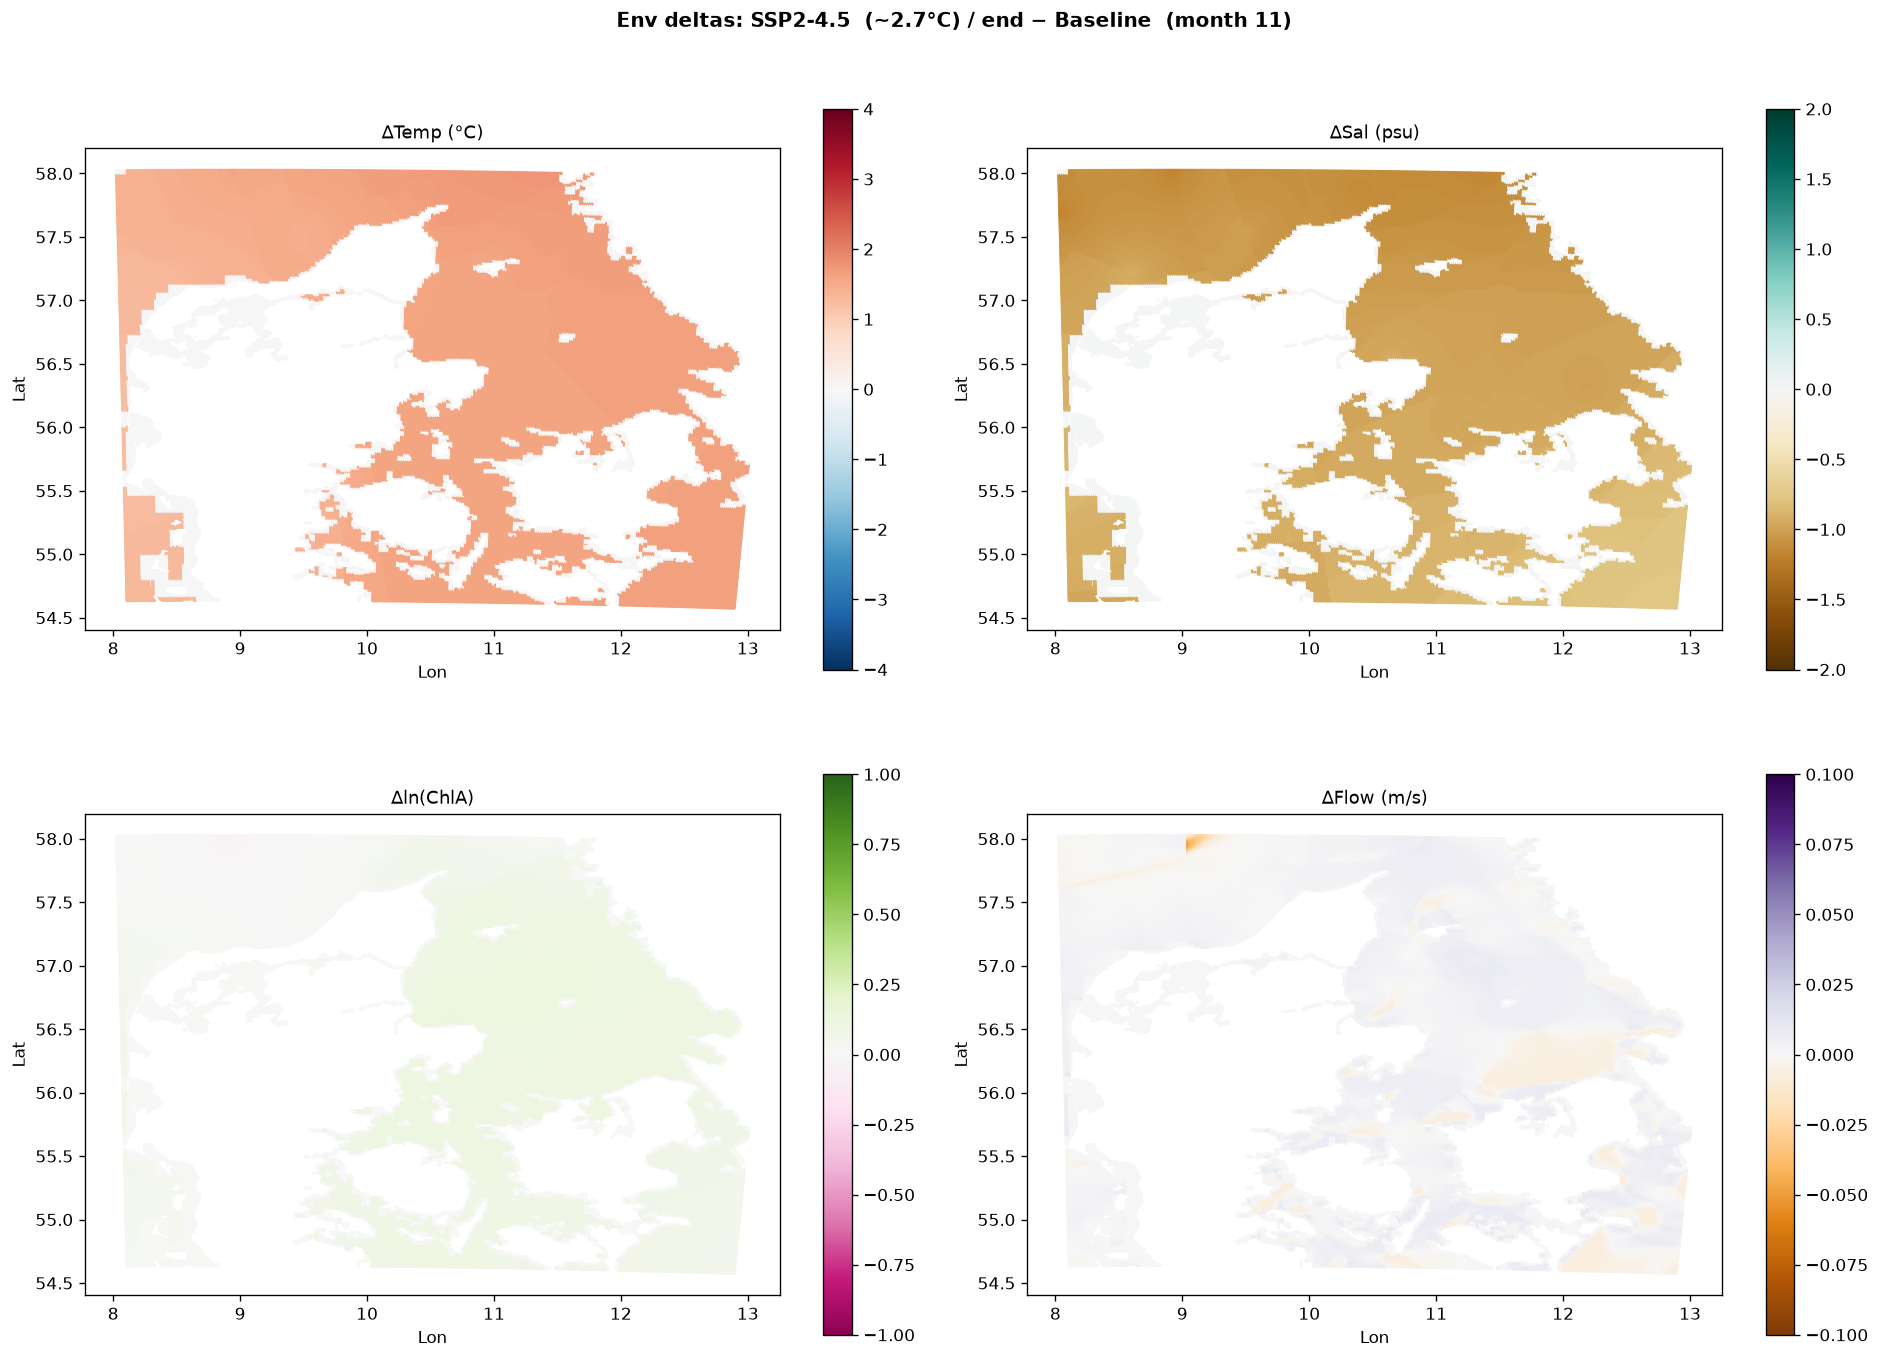

In [5]:
if not SCENARIO_ACTIVE or grid_scenario_env is None:
    print('Scenario not active — skipping env delta maps')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        f'Env deltas: {SSP_SCENARIOS[ACTIVE_SSP]} / {ACTIVE_PERIOD} − Baseline  (month {m})',
        fontsize=12, fontweight='bold'
    )
    env_plots = [
        (f'temp_mean_{m}',   'ΔTemp (°C)',        'RdBu_r', (-4,   4)),
        (f'sal_mean_{m}',    'ΔSal (psu)',         'BrBG',   (-2,   2)),
        (f'lnchla_mean_{m}', 'Δln(ChlA)',          'PiYG',   (-1,   1)),
        (f'vh_{m}',          'ΔFlow (m/s)',        'PuOr',   (-0.1, 0.1)),
    ]
    lons = grid_baseline_env['lon'].values
    lats = grid_baseline_env['lat'].values
    for ax, (col, label, cmap, vlim) in zip(axes.flat, env_plots):
        delta = grid_scenario_env[col].fillna(0).values - grid_baseline_env[col].fillna(0).values
        sc = ax.scatter(lons, lats, c=delta, s=1, cmap=cmap,
                        vmin=vlim[0], vmax=vlim[1], rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.8)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
        ax.set_aspect('equal')
        print(f'  {label:25s}  mean Δ={delta.mean():+.4f}  max Δ={delta.max():+.4f}')
    plt.tight_layout()
    plt.savefig('scenario_env_delta.png', dpi=150, bbox_inches='tight')
    plt.show()

## Cell 6 — M2 mussel growth (baseline + scenario)

In [6]:
print(f'Running M2 baseline ({N_SC} MC scenarios)...')
grid_baseline_m2 = run_module2(grid_baseline_env, n_scenarios=N_SC, n_workers=N_CPU)

p50b = grid_baseline_m2[f'mbio_p50_{m}']
pos  = p50b[p50b > 0]
print(f'\nBaseline mbio p50 (gDW) — month {m}:')
print(f'  Max={p50b.max():.4f}  p90={p50b.quantile(0.9):.4f}  mean={pos.mean():.4f}  viable={len(pos):,}')

if SCENARIO_ACTIVE and grid_scenario_env is not None:
    print(f'\nRunning M2 scenario ({N_SC} MC scenarios)...')
    grid_scenario_m2 = run_module2(grid_scenario_env, n_scenarios=N_SC, n_workers=N_CPU)
    p50s = grid_scenario_m2[f'mbio_p50_{m}']
    pos_s = p50s[p50s > 0]
    print(f'\nScenario mbio p50 (gDW) — month {m}:')
    print(f'  Max={p50s.max():.4f}  p90={p50s.quantile(0.9):.4f}  mean={pos_s.mean():.4f}  viable={len(pos_s):,}')
    print(f'  Δ max={p50s.max()-p50b.max():+.4f}  Δ mean={pos_s.mean()-pos.mean():+.4f} gDW')
else:
    grid_scenario_m2 = None
    print('Scenario not active — M2 scenario skipped')

Running M2 baseline (50 MC scenarios)...

=== Module 2: Mussel Growth (50 sc, 13 workers) ===


  Harvest months (parallel): 100%|██████████| 5/5 [00:07<00:00,  1.58s/it]


  [M2] 08: max=0.094  mean=0.028 gDW  viable=61,060
  [M2] 09: max=0.264  mean=0.080 gDW  viable=61,060
  [M2] 10: max=0.476  mean=0.153 gDW  viable=61,060
  [M2] 11: max=0.655  mean=0.229 gDW  viable=61,060
  [M2] 12: max=0.739  mean=0.291 gDW  viable=61,060

Baseline mbio p50 (gDW) — month 11:
  Max=0.6548  p90=0.3264  mean=0.2287  viable=61,060

Running M2 scenario (50 MC scenarios)...

=== Module 2: Mussel Growth (50 sc, 13 workers) ===


  Harvest months (parallel): 100%|██████████| 5/5 [00:07<00:00,  1.57s/it]


  [M2] 08: max=0.082  mean=0.025 gDW  viable=61,060
  [M2] 09: max=0.242  mean=0.076 gDW  viable=61,060
  [M2] 10: max=0.465  mean=0.153 gDW  viable=61,060
  [M2] 11: max=0.662  mean=0.241 gDW  viable=61,060
  [M2] 12: max=0.788  mean=0.314 gDW  viable=61,060

Scenario mbio p50 (gDW) — month 11:
  Max=0.6625  p90=0.3563  mean=0.2412  viable=61,060
  Δ max=+0.0077  Δ mean=+0.0125 gDW


## Cell 7 — M3 farm upscaling (baseline + scenario)

In [7]:
def compute_rdep(gdf, max_rdep=MAX_RDEP):
    bathy = gdf['bathymetry_m'].fillna(0).values
    rdep  = np.where(bathy - 2 <= max_rdep, np.maximum(bathy - 2, 0), max_rdep)
    rdep  = np.where(bathy >= 4, rdep, 0.0)
    return rdep

grid_baseline_m2['rdep'] = compute_rdep(grid_baseline_m2)
print('Running M3 baseline...')
grid_baseline_m3 = run_module3(grid_baseline_m2)

nr_b = grid_baseline_m3[f'N_red_{m}']
pos_b = nr_b[nr_b > 0]
print(f'\nBaseline N-red (tN) — month {m}:')
print(f'  Max={nr_b.max():.2f}  p90={nr_b.quantile(0.9):.2f}  mean={pos_b.mean():.2f}  viable={len(pos_b):,}')

if SCENARIO_ACTIVE and grid_scenario_m2 is not None:
    grid_scenario_m2['rdep'] = compute_rdep(grid_scenario_m2)
    print('\nRunning M3 scenario...')
    grid_scenario_m3 = run_module3(grid_scenario_m2)
    nr_s  = grid_scenario_m3[f'N_red_{m}']
    pos_s = nr_s[nr_s > 0]
    print(f'\nScenario N-red (tN) — month {m}:')
    print(f'  Max={nr_s.max():.2f}  p90={nr_s.quantile(0.9):.2f}  mean={pos_s.mean():.2f}  viable={len(pos_s):,}')
    print(f'  Δ max={nr_s.max()-nr_b.max():+.2f}  Δ mean={pos_s.mean()-pos_b.mean():+.2f} tN')
else:
    grid_scenario_m3 = None
    print('Scenario not active — M3 scenario skipped')

Running M3 baseline...

=== Module 3: Farm Upscaling ===
  [M3] Using lcol_m from Module 12
  [M3] 08: max=9.8  mean=6.4 tN  viable=55,450
  [M3] 09: max=13.8  mean=9.1 tN  viable=55,450
  [M3] 10: max=16.8  mean=11.3 tN  viable=55,450
  [M3] 11: max=18.6  mean=13.0 tN  viable=55,450
  [M3] 12: max=19.4  mean=14.0 tN  viable=55,450

Baseline N-red (tN) — month 11:
  Max=18.65  p90=14.71  mean=12.96  viable=55,450

Running M3 scenario...

=== Module 3: Farm Upscaling ===
  [M3] Using lcol_m from Module 12
  [M3] 08: max=9.2  mean=6.1 tN  viable=55,450
  [M3] 09: max=13.4  mean=8.9 tN  viable=55,450
  [M3] 10: max=16.6  mean=11.3 tN  viable=55,450
  [M3] 11: max=18.7  mean=13.2 tN  viable=55,450
  [M3] 12: max=19.8  mean=14.3 tN  viable=55,450

Scenario N-red (tN) — month 11:
  Max=18.72  p90=15.16  mean=13.17  viable=55,450
  Δ max=+0.07  Δ mean=+0.22 tN


## Cell 8 — M4 food limitation (baseline + scenario)

In [8]:
print('Running M4 baseline...')
grid_baseline_m4 = run_module4(grid_baseline_m3)

vhb = grid_baseline_m4[f'vh_ratio_{m}'].fillna(np.nan)
lim_b = int((vhb < 0.5).sum())
print(f'Baseline vh_ratio — month {m}:')
print(f'  Median={np.nanmedian(vhb):.3f}  food-limited (vh<0.5): {lim_b:,} cells')

if SCENARIO_ACTIVE and grid_scenario_m3 is not None:
    print('\nRunning M4 scenario...')
    grid_scenario_m4 = run_module4(grid_scenario_m3)
    vhs   = grid_scenario_m4[f'vh_ratio_{m}'].fillna(np.nan)
    lim_s = int((vhs < 0.5).sum())
    print(f'Scenario vh_ratio — month {m}:')
    print(f'  Median={np.nanmedian(vhs):.3f}  food-limited (vh<0.5): {lim_s:,} cells')
    print(f'  Δ food-limited cells: {lim_s-lim_b:+,}')
else:
    grid_scenario_m4 = None
    print('Scenario not active — M4 scenario skipped')

Running M4 baseline...

=== Module 4: Food Limitation ===
  [M4] D_short=240m  rho_col=0.20982
  [M4] Building 5 vectorised LUTs...


  M4 months: 100%|██████████| 5/5 [00:00<00:00, 200.27it/s]


  [M4] 07: OK=8,741  warn=42,251  median_vh_crit=0.3194
  [M4] 08: OK=10,254  warn=40,738  median_vh_crit=0.2969
  [M4] 09: OK=23,530  warn=27,462  median_vh_crit=0.2033
  [M4] 10: OK=26,763  warn=24,229  median_vh_crit=0.1242
  [M4] 11: OK=34,059  warn=16,933  median_vh_crit=0.0901
Baseline vh_ratio — month 11:
  Median=0.791  food-limited (vh<0.5): 16,933 cells

Running M4 scenario...

=== Module 4: Food Limitation ===
  [M4] D_short=240m  rho_col=0.20982
  [M4] Building 5 vectorised LUTs...


  M4 months: 100%|██████████| 5/5 [00:00<00:00, 211.97it/s]

  [M4] 07: OK=6,594  warn=44,398  median_vh_crit=0.3540
  [M4] 08: OK=7,760  warn=43,232  median_vh_crit=0.3307
  [M4] 09: OK=19,430  warn=31,562  median_vh_crit=0.2245
  [M4] 10: OK=24,375  warn=26,617  median_vh_crit=0.1368
  [M4] 11: OK=33,722  warn=17,270  median_vh_crit=0.0937
Scenario vh_ratio — month 11:
  Median=0.743  food-limited (vh<0.5): 17,270 cells
  Δ food-limited cells: +337


## Cell 9 — Output maps

N-red  colour scale: 0 – 15.68 tN    |  diff scale: ±0.62 tN
mbio   colour scale: 0 – 0.3963 gDW  |  diff scale: ±0.0407 gDW


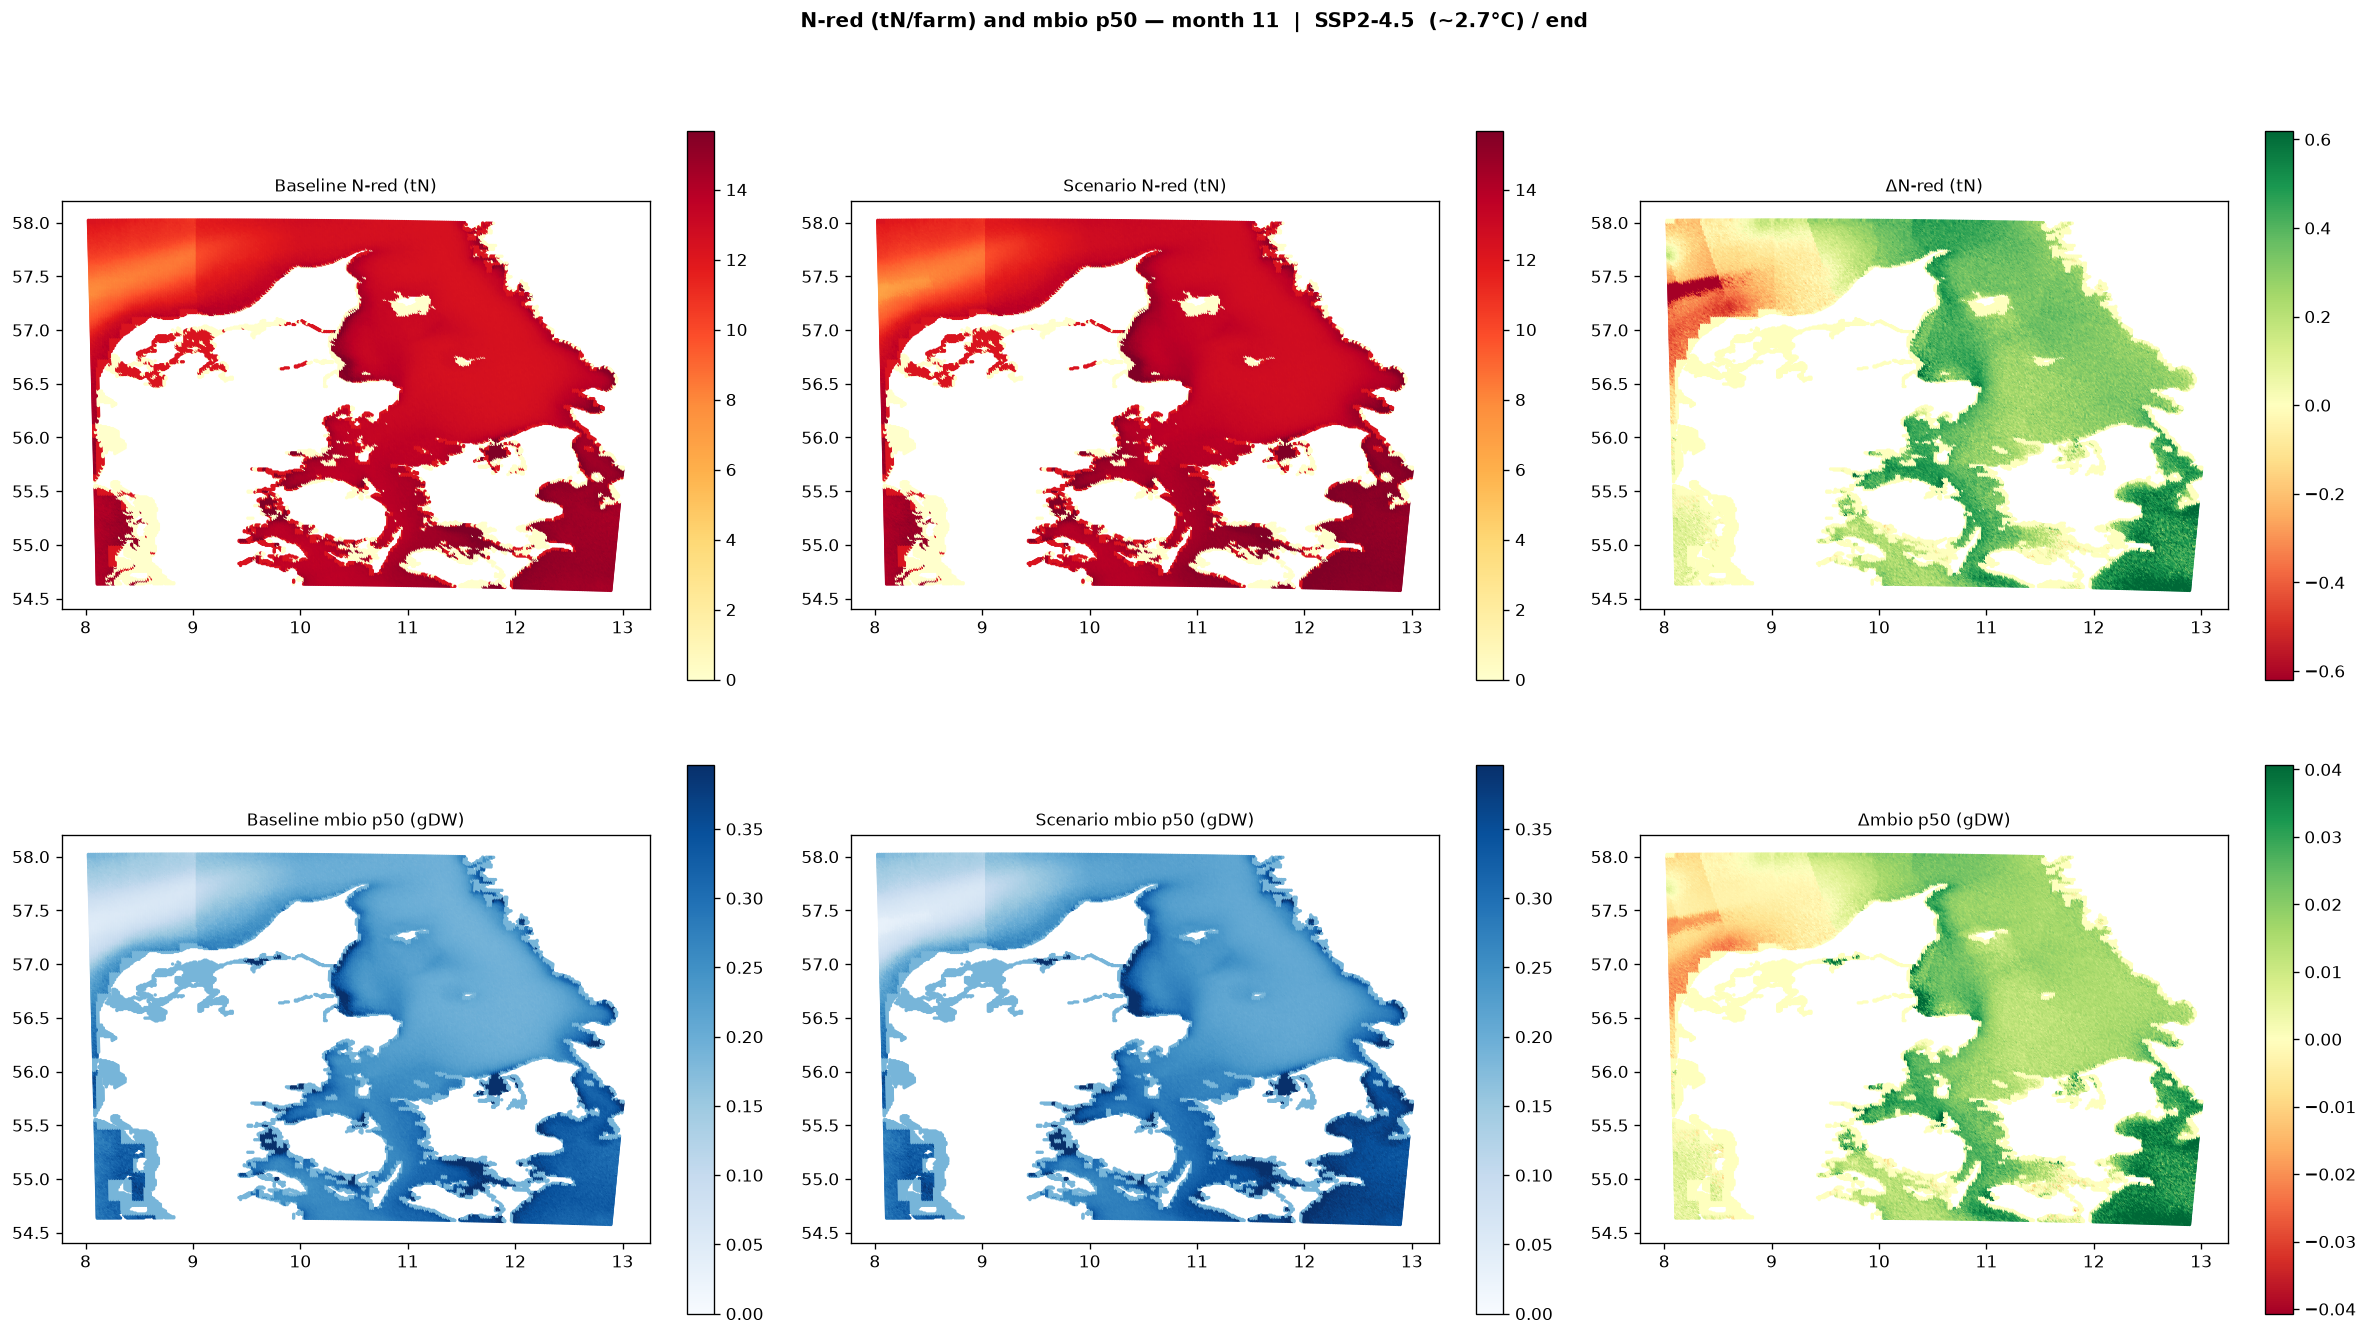

In [9]:
lons = grid_baseline_m4['lon'].values
lats = grid_baseline_m4['lat'].values

if SCENARIO_ACTIVE and grid_scenario_m4 is not None:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(
        f'N-red (tN/farm) and mbio p50 — month {m}  |  {SSP_SCENARIOS[ACTIVE_SSP]} / {ACTIVE_PERIOD}',
        fontsize=12, fontweight='bold'
    )
    col = f'N_red_{m}'
    v_b    = grid_baseline_m4[col].fillna(0).values
    v_s    = grid_scenario_m4[col].fillna(0).values
    v_diff = v_s - v_b
    _all_pos = np.concatenate([v_b[v_b > 0], v_s[v_s > 0]])
    vmax  = float(np.percentile(_all_pos, 98)) if len(_all_pos) else 1.0
    vabs  = float(np.percentile(np.abs(v_diff[v_diff != 0]), 98)) if np.any(v_diff != 0) else 1.0

    col2    = f'mbio_p50_{m}'
    v_b2    = grid_baseline_m4[col2].fillna(0).values
    v_s2    = grid_scenario_m4[col2].fillna(0).values
    v_diff2 = v_s2 - v_b2
    _all_pos2 = np.concatenate([v_b2[v_b2 > 0], v_s2[v_s2 > 0]])
    vmax2 = float(np.percentile(_all_pos2, 98)) if len(_all_pos2) else 1.0
    vabs2 = float(np.percentile(np.abs(v_diff2[v_diff2 != 0]), 98)) if np.any(v_diff2 != 0) else 1.0

    print(f'N-red  colour scale: 0 – {vmax:.2f} tN    |  diff scale: ±{vabs:.2f} tN')
    print(f'mbio   colour scale: 0 – {vmax2:.4f} gDW  |  diff scale: ±{vabs2:.4f} gDW')

    for ax, (vals, title, cmap, vmin, vmx) in zip(axes[0], [
        (v_b,    'Baseline N-red (tN)',    'YlOrRd', 0,     vmax),
        (v_s,    'Scenario N-red (tN)',    'YlOrRd', 0,     vmax),
        (v_diff, 'ΔN-red (tN)',            'RdYlGn', -vabs, vabs),
    ]):
        sc = ax.scatter(lons, lats, c=vals, s=1, cmap=cmap, vmin=vmin, vmax=vmx, rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.75)
        ax.set_title(title, fontsize=10); ax.set_aspect('equal')

    for ax, (vals, title, cmap, vmin, vmx) in zip(axes[1], [
        (v_b2,    'Baseline mbio p50 (gDW)', 'Blues',  0,      vmax2),
        (v_s2,    'Scenario mbio p50 (gDW)', 'Blues',  0,      vmax2),
        (v_diff2, 'Δmbio p50 (gDW)',          'RdYlGn', -vabs2, vabs2),
    ]):
        sc = ax.scatter(lons, lats, c=vals, s=1, cmap=cmap, vmin=vmin, vmax=vmx, rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.75)
        ax.set_title(title, fontsize=10); ax.set_aspect('equal')

else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(f'Baseline outputs — month {m}', fontsize=12, fontweight='bold')
    for ax, (col, title, cmap) in zip(axes, [
        (f'N_red_{m}',    'N-red (tN/farm)',  'YlOrRd'),
        (f'mbio_p50_{m}', 'mbio p50 (gDW)',   'Blues'),
    ]):
        vals = grid_baseline_m4[col].fillna(0).values
        vmax = np.percentile(vals[vals > 0], 98) if (vals > 0).any() else 1
        sc   = ax.scatter(lons, lats, c=vals, s=1, cmap=cmap, vmin=0, vmax=vmax, rasterized=True)
        plt.colorbar(sc, ax=ax, shrink=0.75)
        ax.set_title(title, fontsize=10); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('scenario_output_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
m_check = f'{HARVEST_MONTH:02d}'
ww  = grid_baseline_m4[f'harvest_WW_{m_check}'].mean()
dw  = grid_baseline_m4[f'harvest_DW_{m_check}'].mean()
sdw = grid_baseline_m4[f'shell_DW_{m_check}'].mean()
nr  = grid_baseline_m4[f'N_red_{m_check}'].mean()

print(f'Mean per farm (non-zero cells, month {m_check}):')
print(f'  harvest_WW : {ww:.2f} t WW')
print(f'  harvest_DW : {dw:.2f} t DW  (should be WW/9.68 = {ww/9.68:.2f})')
print(f'  shell_DW   : {sdw:.2f} t    (should be DW×0.77 = {dw*0.77:.2f})')
print(f'  N_red      : {nr:.2f} tN    (should be DW×0.14 = {dw*0.14:.2f})')
print(f'  P_red      : {grid_baseline_m4[f"P_red_{m_check}"].mean():.3f} tP  (should be DW×0.008 = {dw*0.008:.3f})')

Mean per farm (non-zero cells, month 11):
  harvest_WW : 813.59 t WW
  harvest_DW : 84.05 t DW  (should be WW/9.68 = 84.05)
  shell_DW   : 64.72 t    (should be DW×0.77 = 64.72)
  N_red      : 11.77 tN    (should be DW×0.14 = 11.77)
  P_red      : 0.672 tP  (should be DW×0.008 = 0.672)


## Cell 10 — Summary table

In [10]:
def stats(gdf, col):
    v   = gdf[col].fillna(0).values
    pos = v[v > 0]
    return {'max': round(v.max(), 3), 'p90': round(np.percentile(v, 90), 3),
            'mean': round(pos.mean(), 3) if len(pos) else 0.0, 'viable': int(len(pos))}

output_cols = [
    (f'N_red_{m}',       'tN/farm'),
    (f'N_red_p05_{m}',   'tN/farm p05'),
    (f'N_red_p95_{m}',   'tN/farm p95'),
    (f'harvest_WW_{m}',  't WW/farm'),
    (f'shell_DW_{m}',    't shell DW/farm'),
    (f'mbio_p50_{m}',    'gDW/mussel'),
    (f'mbio_p05_{m}',    'gDW p05'),
    (f'mbio_p95_{m}',    'gDW p95'),
]

rows = []
for col, unit in output_cols:
    if col not in grid_baseline_m4.columns:
        continue
    sb = stats(grid_baseline_m4, col)
    row = {'metric': col.replace(f'_{m}',''), 'unit': unit,
           'base_max': sb['max'], 'base_p90': sb['p90'],
           'base_mean': sb['mean'], 'base_viable': sb['viable']}
    if SCENARIO_ACTIVE and grid_scenario_m4 is not None and col in grid_scenario_m4.columns:
        ss = stats(grid_scenario_m4, col)
        row.update({'scen_max': ss['max'], 'scen_p90': ss['p90'],
                    'scen_mean': ss['mean'], 'scen_viable': ss['viable'],
                    'Δ_max': round(ss['max']-sb['max'],3),
                    'Δ_mean': round(ss['mean']-sb['mean'],3)})
    rows.append(row)

df = pd.DataFrame(rows).set_index('metric')
display(df)

,unit,base_max,base_p90,base_mean,base_viable,scen_max,scen_p90,scen_mean,scen_viable,Δ_max,Δ_mean
metric,,,,,,,,,,,
N_red,tN/farm,18.645,14.708,12.957,55450,18.718,15.157,13.175,55450,0.073,0.218
N_red_p05,tN/farm p05,17.571,13.728,12.277,55450,17.649,14.141,12.465,55450,0.078,0.188
N_red_p95,tN/farm p95,19.677,15.679,13.600,55450,20.011,16.139,13.840,55450,0.334,0.240
harvest_WW,t WW/farm,1289.181,1016.947,895.902,55450,1294.195,1048.030,910.926,55450,5.014,15.024
shell_DW,t shell DW/farm,102.549,80.894,71.265,55450,102.947,83.366,72.460,55450,0.398,1.195
mbio_p50,gDW/mussel,0.655,0.326,0.229,61060,0.662,0.356,0.241,61060,0.007,0.012
mbio_p05,gDW p05,0.551,0.264,0.195,61060,0.559,0.288,0.205,61060,0.008,0.010
mbio_p95,gDW p95,0.770,0.397,0.265,61060,0.810,0.432,0.280,61060,0.040,0.015


## Cell 11 — Sanity checks

In [11]:
print('=== Sanity checks ===')

# 1. Non-env columns unchanged in scenario env grid
if SCENARIO_ACTIVE and grid_scenario_env is not None:
    print('Non-env columns preserved in scenario env grid:')
    for col in ['bathymetry_m', 'cell_id', 'excluded']:
        if col in grid_baseline_env.columns and col in grid_scenario_env.columns:
            match = np.allclose(
                grid_baseline_env[col].fillna(-999).values,
                grid_scenario_env[col].fillna(-999).values,
            )
            print(f'  {col:20s} unchanged={match}  (should be True)')

    # 2. Env columns differ
    print('\nEnv columns changed in scenario env grid:')
    for col in [f'temp_mean_{m}', f'sal_mean_{m}', f'lnchla_mean_{m}']:
        b = grid_baseline_env[col].mean()
        s = grid_scenario_env[col].mean()
        same = np.isclose(b, s, atol=1e-6)
        print(f'  {col:25s} same={same}  (should be False)  Δ={s-b:+.4f}')


    # ChlA sanity: test July (peak bloom) directly from env grids — independent of HARVEST_MONTH
    for col in ['lnchla_mean_07', 'lnchla_mean_04', f'lnchla_mean_{m}']:
        if col not in grid_baseline_env.columns:
            continue
        b = grid_baseline_env[col].mean()
        s = grid_scenario_env[col].mean()
        same = np.isclose(b, s, atol=1e-6)
        print(f'  {col:25s} same={same}  (should be False)  Δ={s-b:+.4f}')




    # 3. N_red differs
    if grid_scenario_m4 is not None:
        nr_b = grid_baseline_m4[f'N_red_{m}'].fillna(0).values
        nr_s = grid_scenario_m4[f'N_red_{m}'].fillna(0).values
        print(f'\nN_red identical to baseline: {np.allclose(nr_b, nr_s)}  (should be False)')
        print(f'Mean ΔN_red: {(nr_s-nr_b).mean():+.4f} tN/farm')

# 4. shell_DW present
shell_col = f'shell_DW_{m}'
has_shell = shell_col in grid_baseline_m4.columns
print(f'\nshell_DW column present (baseline): {has_shell}')
if has_shell:
    sv = grid_baseline_m4[shell_col]
    print(f'  max={sv.max():.3f}  mean={sv[sv>0].mean():.3f} t shell DW/farm')

print('\n=== Done ===')

=== Sanity checks ===
Non-env columns preserved in scenario env grid:
  bathymetry_m         unchanged=True  (should be True)
  cell_id              unchanged=True  (should be True)
  excluded             unchanged=True  (should be True)

Env columns changed in scenario env grid:
  temp_mean_11              same=False  (should be False)  Δ=+1.5757
  sal_mean_11               same=False  (should be False)  Δ=-0.9818
  lnchla_mean_11            same=False  (should be False)  Δ=+0.0741
  lnchla_mean_07            same=False  (should be False)  Δ=-0.1204
  lnchla_mean_04            same=False  (should be False)  Δ=-0.2309
  lnchla_mean_11            same=False  (should be False)  Δ=+0.0741

N_red identical to baseline: False  (should be False)
Mean ΔN_red: +0.1973 tN/farm

shell_DW column present (baseline): True
  max=102.549  mean=71.265 t shell DW/farm

=== Done ===


In [ ]:
# ##DEBUGGGG
# # Paste this in a new cell to debug the chla delta directly
# import glob
# import xarray as xr
# import numpy as np
# from pathlib import Path
# from config import PROCESSED

# RAW_DIR = PROCESSED / "cmip6_raw"
# HIST_DATE = ("1985-01-01", "2014-12-31")

# # Open historical chl
# import glob
# hist_files = sorted(glob.glob(str(RAW_DIR / "historical_esgf_chl" / "chl_*.nc")))
# fut_files  = sorted(glob.glob(str(RAW_DIR / "ssp2_4_5_esgf_chl"  / "chl_*.nc")))

# print(f"Historical chl files: {len(hist_files)}")
# print(f"Future chl files    : {len(fut_files)}")

# if hist_files:
#     ds_h = xr.open_mfdataset(hist_files, combine="by_coords",
#                               decode_times=xr.coders.CFDatetimeCoder(use_cftime=True))
#     ds_h_sliced = ds_h.sel(time=slice("1985-01-01","2014-12-31"))
#     print(f"\nHistorical chl time range: {ds_h_sliced.time.values[0]} → {ds_h_sliced.time.values[-1]}")
#     print(f"Historical chl mean: {float(ds_h_sliced['chl'].mean()):.6f}")

# if fut_files:
#     ds_f = xr.open_mfdataset(fut_files, combine="by_coords",
#                               decode_times=xr.coders.CFDatetimeCoder(use_cftime=True))
#     ds_f_sliced = ds_f.sel(time=slice("2071-01-01","2100-12-31"))
#     print(f"\nFuture chl time range  : {ds_f_sliced.time.values[0]} → {ds_f_sliced.time.values[-1]}")
#     print(f"Future chl mean        : {float(ds_f_sliced['chl'].mean()):.6f}")
    
#     if hist_files:
#         h_mean = float(ds_h_sliced['chl'].mean())
#         f_mean = float(ds_f_sliced['chl'].mean())
#         print(f"\nRaw delta (linear)     : {f_mean - h_mean:+.6f}")
#         print(f"Log delta              : {np.log(max(f_mean,0.01)) - np.log(max(h_mean,0.01)):+.6f}")


# ##DEBUG
# # Add to the same debug cell
# if hist_files:
#     chl_vals = ds_h_sliced['chl'].values
#     print(f"\nHistorical chl:")
#     print(f"  dtype  : {chl_vals.dtype}")
#     print(f"  min    : {float(np.nanmin(chl_vals)):.2e}")
#     print(f"  max    : {float(np.nanmax(chl_vals)):.2e}")
#     print(f"  mean   : {float(np.nanmean(chl_vals)):.2e}")
#     print(f"  NaN %  : {100*np.isnan(chl_vals).mean():.1f}%")
#     print(f"  units  : {ds_h_sliced['chl'].attrs.get('units', 'not set')}")

# if fut_files:
#     chl_vals_f = ds_f_sliced['chl'].values
#     print(f"\nFuture chl:")
#     print(f"  min    : {float(np.nanmin(chl_vals_f)):.2e}")
#     print(f"  max    : {float(np.nanmax(chl_vals_f)):.2e}")
#     print(f"  mean   : {float(np.nanmean(chl_vals_f)):.2e}")
#     print(f"  units  : {ds_f_sliced['chl'].attrs.get('units', 'not set')}")

# EXPORT DATA

In [14]:
# ── Export Cell — paste into scenario_test.ipynb ──────────────────────────────
# Exports two CSVs per active grid (baseline, and scenario if active):
#   mytigate_env_{label}.csv     — M1 environmental fields (all 12 months)
#   mytigate_results_{label}.csv — M2/M3/M4 outputs (harvest months only)
# Files saved next to the notebook. Join to Rhino grid on cell_id.

from pathlib import Path
import pandas as pd
import numpy as np

EXPORT_DIR = Path('.')   # change to a subfolder if preferred e.g. Path('exports')
EXPORT_DIR.mkdir(exist_ok=True)

HARVEST_MONTHS_STR = [f'{h:02d}' for h in [8, 9, 10, 11, 12]]
ALL_MONTHS_STR     = [f'{i:02d}' for i in range(1, 13)]

def _env_cols(grid):
    """All M1 env columns present in grid."""
    cols = ['cell_id', 'lon', 'lat', 'bathymetry_m']
    for prefix in ['temp_mean_', 'sal_mean_', 'lnchla_mean_', 'vh_']:
        cols += [f'{prefix}{mk}' for mk in ALL_MONTHS_STR
                 if f'{prefix}{mk}' in grid.columns]
    return [c for c in cols if c in grid.columns]

def _result_cols(grid):
    """All M2/M3/M4 result columns present in grid."""
    cols = ['cell_id', 'lon', 'lat', 'excluded', 'conflict_score', 'rdep']
    for prefix in [
        'harvest_WW_', 'harvest_DW_', 'shell_DW_',
        'N_red_', 'N_red_ha_',
        'P_red_',
        'mbio_p50_',
        'vh_ratio_', 'food_limitation_',
    ]:
        cols += [f'{prefix}{mk}' for mk in HARVEST_MONTHS_STR
                 if f'{prefix}{mk}' in grid.columns]
    return [c for c in cols if c in grid.columns]

def export_grid(grid, label):
    """Export env + results CSVs for one grid. Returns (env_path, results_path)."""
    # Strip geometry if GeoDataFrame
    if hasattr(grid, 'drop'):
        df = pd.DataFrame(grid.drop(columns='geometry', errors='ignore'))
    else:
        df = pd.DataFrame(grid)

    env_path     = EXPORT_DIR / f'mytigate_env_{label}.csv'
    results_path = EXPORT_DIR / f'mytigate_results_{label}.csv'

    env_df     = df[_env_cols(grid)]
    results_df = df[_result_cols(grid)]

    env_df.to_csv(env_path,     index=False, float_format='%.6f')
    results_df.to_csv(results_path, index=False, float_format='%.4f')

    print(f'\n[{label}]')
    print(f'  env     → {env_path.name}  '
          f'({len(env_df):,} rows × {len(env_df.columns)} cols, '
          f'{env_path.stat().st_size/1024:.0f} KB)')
    print(f'  results → {results_path.name}  '
          f'({len(results_df):,} rows × {len(results_df.columns)} cols, '
          f'{results_path.stat().st_size/1024:.0f} KB)')
    return env_path, results_path

# ── Run export ────────────────────────────────────────────────────────────────
print('=== Exporting CSVs ===')

export_grid(grid_baseline_m4, 'baseline')

if SCENARIO_ACTIVE and grid_scenario_m4 is not None:
    scen_label = f'{ACTIVE_SSP}_{ACTIVE_PERIOD}'
    export_grid(grid_scenario_m4, scen_label)
    print(f'\nScenario label: {SSP_SCENARIOS[ACTIVE_SSP]} / {ACTIVE_PERIOD}')
else:
    print('\nScenario not active — baseline only exported')

print('\n=== Export complete ===')

=== Exporting CSVs ===

[baseline]
  env     → mytigate_env_baseline.csv  (61,060 rows × 52 cols, 25864 KB)
  results → mytigate_results_baseline.csv  (61,060 rows × 49 cols, 21555 KB)

[ssp2_4_5_end]
  env     → mytigate_env_ssp2_4_5_end.csv  (61,060 rows × 52 cols, 26019 KB)
  results → mytigate_results_ssp2_4_5_end.csv  (61,060 rows × 49 cols, 21575 KB)

Scenario label: SSP2-4.5  (~2.7°C) / end

=== Export complete ===
